# Data preprocessing and Model creation for ALDIMI D1

# 0. Data loading and initial configuration

Import libraries

In [334]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load data

In [335]:
df_raw = pd.read_csv("../data/raw/ALDIMI_dataset_sintetico_300.csv")

## 1. Data Preprocessing
Based on the EDA, we saw that the synthetized data had good distributions and outliers that were useful and should not be erased

In [336]:
# Try to treat outliers
outlier_variables = ['valor_stock_total']

for column in outlier_variables:
    pmax = np.percentile(df_raw[column], 98)
    pmin = np.percentile(df_raw[column], 2)
    df_raw[column] = np.clip(df_raw[column], pmin, pmax)

In [337]:
# Export data
df_raw.to_csv("../data/processed/processed_data.csv", index=False)

## 2. Model training

### 2.1. Initial data preparation

Load processed data

In [338]:
df_processed = pd.read_csv("../data/processed/processed_data.csv")

Define our target variable

In [339]:
target = 'gasto_total_diario'

Columns not to use

In [340]:
no_columns = []

Separate data in train and test

In [341]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=[target])
y = df_processed[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2.2. Create and train the model (Random Forest)

Create the model

In [342]:
model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

Train using data

In [343]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

Doing the predictions

In [344]:
y_pred = model.predict(X_test)

### 2.3 Model Evaluation (Random Forest)

In [345]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("RESULT METRICS: ")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

RESULT METRICS: 
MAE: 30.127582775906795
RMSE: 36.07278664898007
R2: 0.7941778547616531


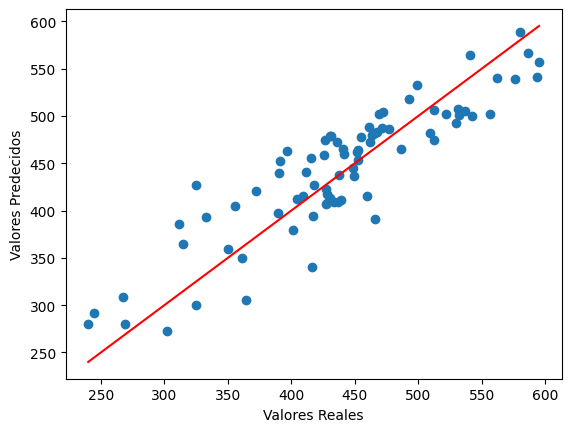

In [346]:
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predecidos")
plt.show()

Importancia de cada feature

In [347]:
coef = pd.DataFrame({
    "feature": X.columns,
    "coef": model.feature_importances_
})
print(coef.sort_values(by="coef", ascending=False))

               feature      coef
3           gasto_ayer  0.728105
6    valor_stock_total  0.100724
4      promedio_3_dias  0.075212
2   personas_atendidas  0.056825
5      promedio_7_dias  0.014859
7  inflacion_alimentos  0.013365
0           dia_semana  0.006752
1                  mes  0.004159


### 2.4 Create and train the model (Linear Regression)

Create the model

In [348]:
model = LinearRegression()

Train using data

In [349]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Do the predictions

In [350]:
y_pred = model.predict(X_test)

### 2.5 Model Evaluation (Linear Regression)

In [351]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("RESULT METRICS: ")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

RESULT METRICS: 
MAE: 25.047023269522196
RMSE: 30.000041119821653
R2: 0.8576437909978687


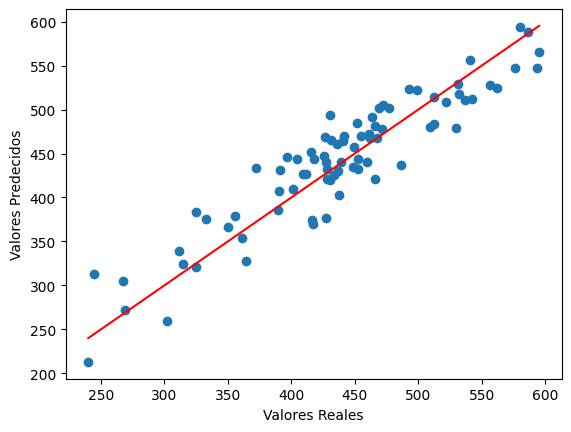

In [352]:
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predecidos")
plt.show()

Importancia de cada feature

In [353]:
coef = pd.DataFrame({
    "feature": X.columns,
    "importance": model.coef_
})
coef["importance"] = abs(coef["importance"])
coef = coef.sort_values(by="importance", ascending=False)
print(coef)

               feature  importance
7  inflacion_alimentos   31.555028
2   personas_atendidas    2.120903
1                  mes    1.111207
0           dia_semana    1.094764
3           gasto_ayer    0.364466
5      promedio_7_dias    0.218750
6    valor_stock_total    0.069992
4      promedio_3_dias    0.022392


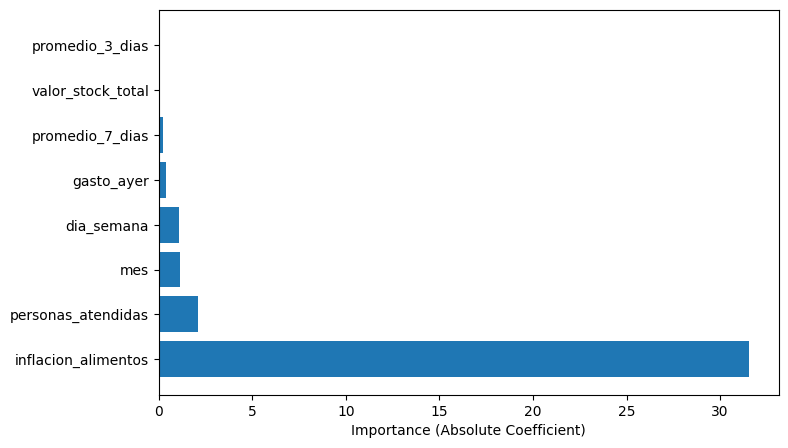

In [354]:
plt.figure(figsize=(8, 5))
plt.barh(
    coef["feature"],
    coef["importance"]
)
plt.xlabel("Importance (Absolute Coefficient)")
plt.show()